In [1]:
import numpy as np
import scanpy as sc
import pandas as pd
from scipy.stats import mannwhitneyu
from pyucell import compute_ucell_scores
import matplotlib.pyplot as plt
import re

# SIGMA vs UCell — Tem cytotoxic T cell extraction
## Dominguez et al. cross-tissue human immune atlas (Science, 2022)

**Comparison of SIGMA and UCell (v2, combined positive/negative signatures)
for the targeted extraction of effector memory cytotoxic T cells.**

### Datasets
- Full dataset: Dominguez Conde et al., Science 2022
  (doi: 10.1126/science.abl5197)
- SIGMA output: merge.h5ad produced by the SIGMA pipeline
  (score threshold >= 0.95)

### UCell reference
- Andreatta & Carmona, Bioinformatics 2026
  (doi: 10.1093/bioinformatics/btag055)

### Validation approach
Selections are evaluated using three biologically unambiguous
marker panels, independent of clustering or annotation quality:
- T cell identity markers (CD3E, TRAC, CD8A, CD8B)
- NK cell contamination markers (NCAM1, KLRD1, FCGR3A, GNLY)
- Non-cytotoxic T cell markers (CD4, FOXP3, TCF7, SELL)

---
## Configuration

In [2]:
# --- Paths ---
PATH_FULL  = (
    "/home/lemgui01/raw_STUDIES_thesis/healthy/"
    "Dominguez_science_science-abl5197.h5ad"
)
PATH_SIGMA = (
    "/mnt/projects_tn03/AD_EB_singlecell/article/"
    "results_dominguez/merge.h5ad"
)

# --- SIGMA threshold ---
SIGMA_THRESHOLD = 0.95

# --- UCell threshold ---
UCELL_PERCENTILE = 99

# --- Signatures ---
TEM_POSITIVE = ["IL7R", "PRF1", "NKG7", "CX3CR1",
                "GZMB", "GZMK", "CD44"]

TEM_NEGATIVE = ["SELL", "TCF7", "TRGC1", "CXCR5",
                "FOXP3", "LEF1", "TRDC", "CCR7",
                "TRGC2", "CD27"]

TEM_UCELL_COMBINED = ([f"{g}+" for g in TEM_POSITIVE] +
                      [f"{g}-" for g in TEM_NEGATIVE])

# --- Validation marker panels ---
T_CELL_MARKERS = ["CD3E", "TRAC", "CD8A", "CD8B"]
NK_MARKERS     = ["NCAM1", "KLRD1", "FCGR3A", "GNLY"]
NON_CYTOTOXIC  = ["CD4", "FOXP3", "TCF7", "SELL"]

# --- Plot colors ---
GREEN  = "#2ecc71"   # SIGMA+
ORANGE = "#e67e22"   # UCell+
rng    = np.random.default_rng(42)

---
## 1. Data loading

In [3]:
adata_full  = sc.read_h5ad(PATH_FULL)
adata_sigma = sc.read_h5ad(PATH_SIGMA)

print(f"adata_full  : {adata_full.shape[0]:,} cells x {adata_full.shape[1]:,} genes")
print(f"adata_sigma : {adata_sigma.shape[0]:,} cells x {adata_sigma.shape[1]:,} genes")

adata_full  : 329,762 cells x 36,601 genes
adata_sigma : 41,214 cells x 36,601 genes


---
## 2. SIGMA+ labeling

In [4]:
adata_sigma_thresh = adata_sigma[adata_sigma.obs["score"] >= SIGMA_THRESHOLD].copy()

adata_sigma_thresh.obs_names = adata_sigma_thresh.obs_names.str.replace(
    r"-Dominguez_.*?_data$", "", regex=True
)

adata_full.obs["sigma_positive"] = (
    adata_full.obs_names.isin(set(adata_sigma_thresh.obs_names))
)

print(f"SIGMA+ : {adata_full.obs['sigma_positive'].sum():,}")

SIGMA+ : 2,698


---
## 3. UCell score computation and thresholding

UCell threshold (99th pct) : 0.5271
SIGMA+ : 2,698
UCell+ : 3,298
Overlap: 261


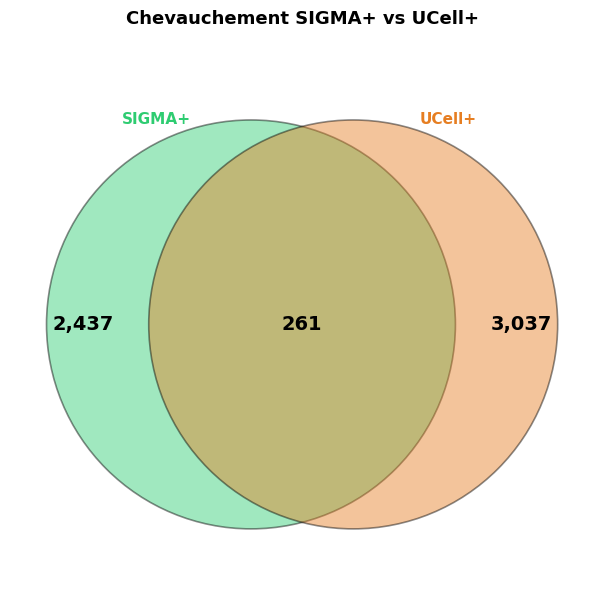

In [5]:
compute_ucell_scores(
    adata_full,
    {"tem_combined": TEM_UCELL_COMBINED},
    suffix="_UCell"
)

ucell_threshold = np.percentile(
    adata_full.obs["tem_combined_UCell"], UCELL_PERCENTILE
)

adata_full.obs["ucell_positive"] = (
    adata_full.obs["tem_combined_UCell"] >= ucell_threshold
)

mask_sigma = adata_full.obs["sigma_positive"]
mask_ucell = adata_full.obs["ucell_positive"]

print(f"UCell threshold ({UCELL_PERCENTILE}th pct) : {ucell_threshold:.4f}")
print(f"SIGMA+ : {mask_sigma.sum():,}")
print(f"UCell+ : {mask_ucell.sum():,}")
print(f"Overlap: {(mask_sigma & mask_ucell).sum():,}")

n_sigma = int(mask_sigma.sum())
n_ucell = int(mask_ucell.sum())
n_both = int((mask_sigma & mask_ucell).sum())

n_sigma_only = n_sigma - n_both
n_ucell_only = n_ucell - n_both

fig, ax = plt.subplots(figsize=(7, 6))

c1 = plt.Circle((0.43, 0.5), 0.28, color=GREEN, alpha=0.45, ec="black", lw=1.2)
c2 = plt.Circle((0.57, 0.5), 0.28, color=ORANGE, alpha=0.45, ec="black", lw=1.2)
ax.add_patch(c1)
ax.add_patch(c2)

ax.text(0.20, 0.50, f"{n_sigma_only:,}", ha="center", va="center",
    fontsize=14, fontweight="bold")
ax.text(0.50, 0.50, f"{n_both:,}", ha="center", va="center",
    fontsize=14, fontweight="bold")
ax.text(0.80, 0.50, f"{n_ucell_only:,}", ha="center", va="center",
    fontsize=14, fontweight="bold")

ax.text(0.30, 0.78, "SIGMA+", ha="center", va="center",
    fontsize=11, fontweight="bold", color=GREEN)
ax.text(0.70, 0.78, "UCell+", ha="center", va="center",
    fontsize=11, fontweight="bold", color=ORANGE)

ax.set_title("Chevauchement SIGMA+ vs UCell+", fontsize=13, fontweight="bold")
ax.set_xlim(0.1, 0.9)
ax.set_ylim(0.15, 0.9)
ax.set_aspect("equal")
ax.axis("off")

plt.tight_layout()
fig.savefig("figures/sup_venn_sigma_ucell.svg", bbox_inches="tight", dpi=500)
plt.show()

---
## 4. log1p-CPM normalization

In [6]:
adata_norm = adata_full.copy()
sc.pp.normalize_total(adata_norm, target_sum=1e6)
sc.pp.log1p(adata_norm)

---
## 5. Utility functions

In [14]:
def get_expression(adata, mask, gene):
    if gene not in adata.var_names:
        return np.array([])
    idx = adata.var_names.get_loc(gene)
    expr = adata.X[mask, idx]
    if hasattr(expr, "toarray"):
        expr = expr.toarray().flatten()
    return np.array(expr).flatten()

def mean_panel(adata, mask, genes):
    genes_ok = [g for g in genes if g in adata.var_names]
    if not genes_ok:
        return np.zeros(int(mask.sum()))
    idx = [adata.var_names.get_loc(g) for g in genes_ok]
    expr = adata.X[mask][:, idx]
    if hasattr(expr, "toarray"):
        expr = expr.toarray()
    return np.mean(expr, axis=1)

def format_pvalue(pval):
    return f"{pval:.3e}"

def boxplot_panel(ax, v1, v2, title, rng, n_sample=200):
    """Boxplot + stripplot comparing SIGMA+ (green) vs UCell+ (orange)."""
    for i, (vals, color) in enumerate(
        [(v1, GREEN), (v2, ORANGE)], start=1
    ):
        bp = ax.boxplot(
            [v1, v2][i - 1:i],
            positions=[i], patch_artist=True, widths=0.5,
            notch=False, showfliers=False,
            medianprops=dict(color="black", linewidth=2), zorder=3
        )
        bp["boxes"][0].set_facecolor(color)
        bp["boxes"][0].set_alpha(0.75)
        for w in bp["whiskers"]: w.set(linewidth=1.0, linestyle="--")
        for c in bp["caps"]:     c.set(linewidth=1.0)

        s   = rng.choice(len(vals), size=min(n_sample, len(vals)),
                         replace=False)
        jit = rng.uniform(-0.12, 0.12, size=len(s))
        ax.scatter(i + jit, vals[s], color=color,
                   alpha=0.3, s=6, zorder=2, linewidths=0)

    stat, pval = mannwhitneyu(v1, v2, alternative="two-sided")

    ax.set_title(title + f"\np = {format_pvalue(pval)}", fontsize=11, fontweight="bold")

    ax.set_xticks([1, 2])
    ax.set_xticklabels(
        [f"SIGMA+\n(n={len(v1):,})", f"UCell+\n(n={len(v2):,})"],
        fontsize=9
    )
    ax.set_ylabel("log1p-CPM", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return pval

def plot_gene_panel(genes, suptitle, figname, rng, n_cols=4, n_sample=200):
    genes_ok = [g for g in genes if g in adata_norm.var_names]
    n_rows   = int(np.ceil(len(genes_ok) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
    axes = axes.flatten()
    for idx, gene in enumerate(genes_ok):
        boxplot_panel(axes[idx],
                      get_expression(adata_norm, mask_sigma.values, gene),
                      get_expression(adata_norm, mask_ucell.values, gene),
                      gene, rng, n_sample)
    for idx in range(len(genes_ok), len(axes)):
        axes[idx].axis("off")
    fig.suptitle(suptitle, fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(f"{figname}.svg", bbox_inches="tight", dpi=500)
    plt.show()

---
## 6. Figure 1 — T cell identity markers
CD3E, TRAC, CD8A, CD8B must be HIGH in true CD8+ T cells.

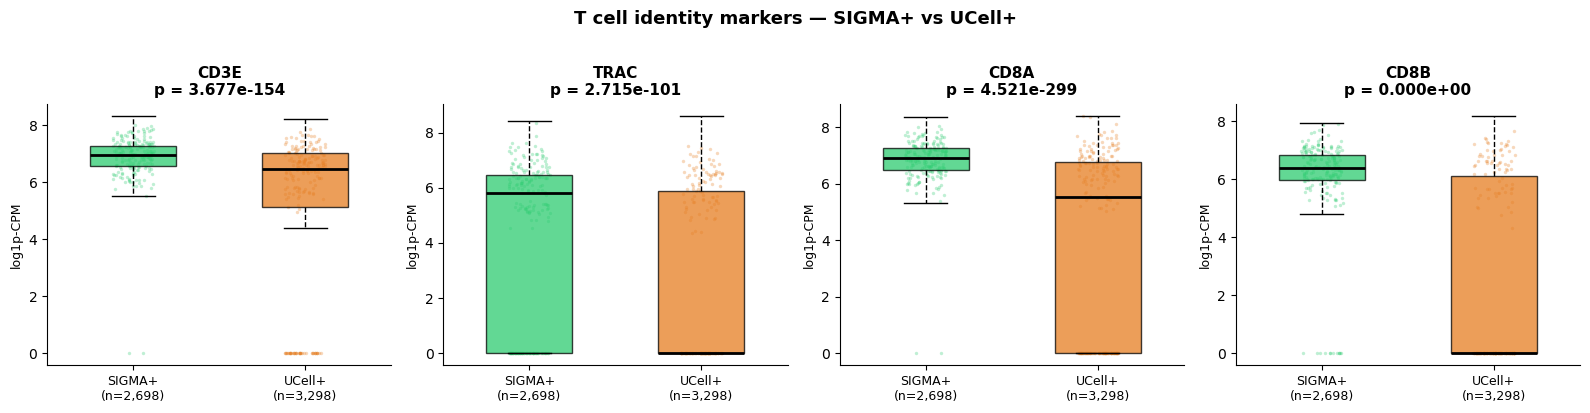

In [15]:
plot_gene_panel(
    T_CELL_MARKERS,
    "T cell identity markers — SIGMA+ vs UCell+",
    "figures/sup_tcell_markers",
    rng
)

---
## 7. Figure 2 — NK cell contamination markers
NCAM1, KLRD1, FCGR3A, GNLY must be LOW in a pure T cell selection.

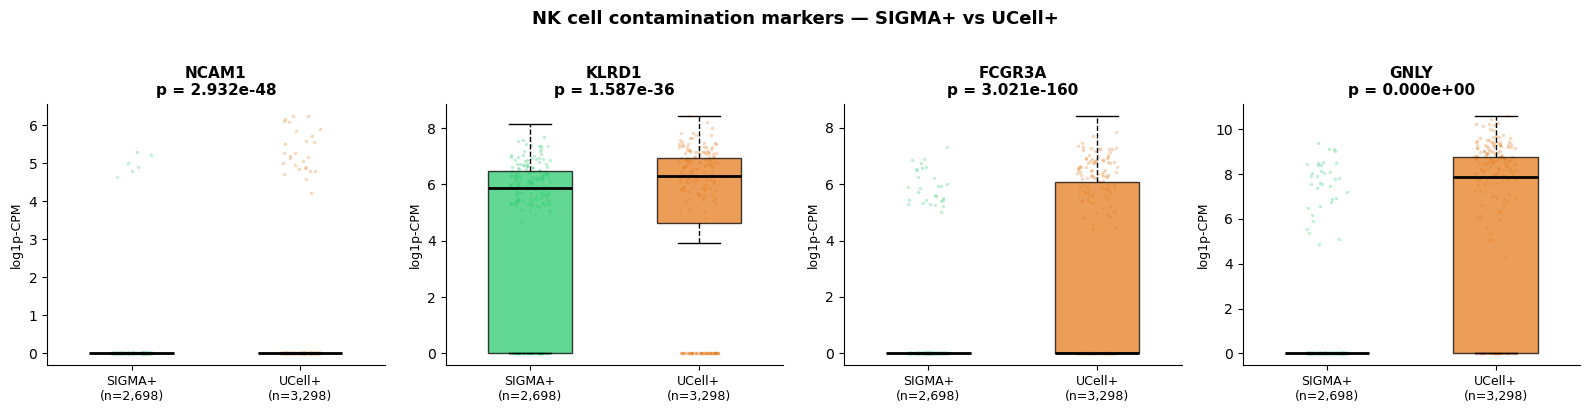

In [16]:
plot_gene_panel(
    NK_MARKERS,
    "NK cell contamination markers — SIGMA+ vs UCell+",
    "figures/sup_nk_markers",
    rng
)

---
## 8. Figure 3 — Non-cytotoxic T cell markers
CD4, FOXP3, TCF7, SELL must be LOW in an effector memory selection.

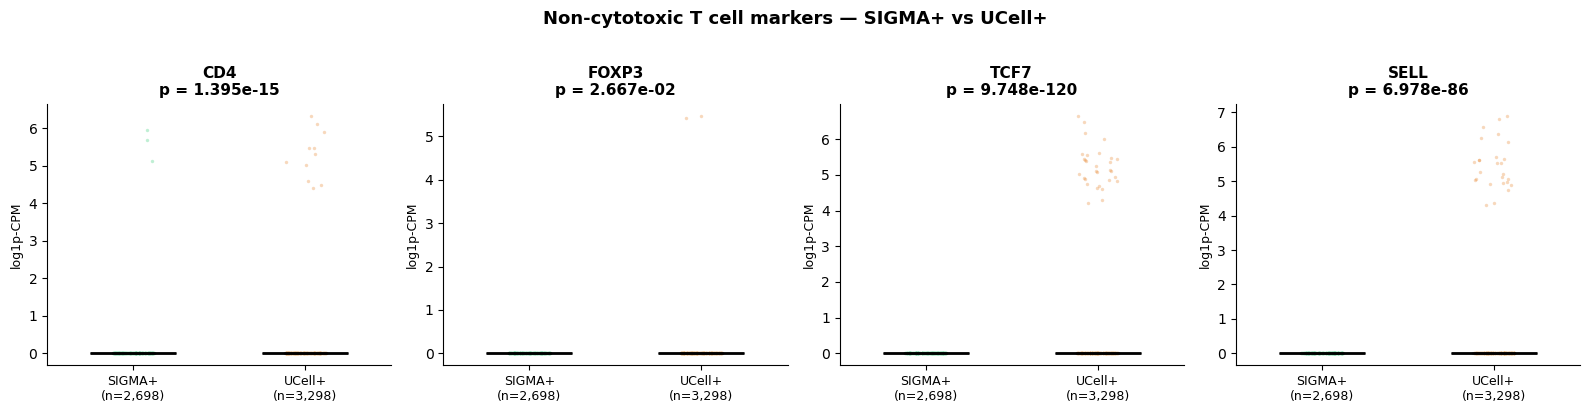

In [17]:
plot_gene_panel(
    NON_CYTOTOXIC,
    "Non-cytotoxic T cell markers — SIGMA+ vs UCell+",
    "figures/sup_noncytotoxic_markers",
    rng
)

---
## 9. Figure 4 — CD3E-negative cell fraction
Fraction of CD3E-negative cells is the most direct measure
of non-T cell contamination.

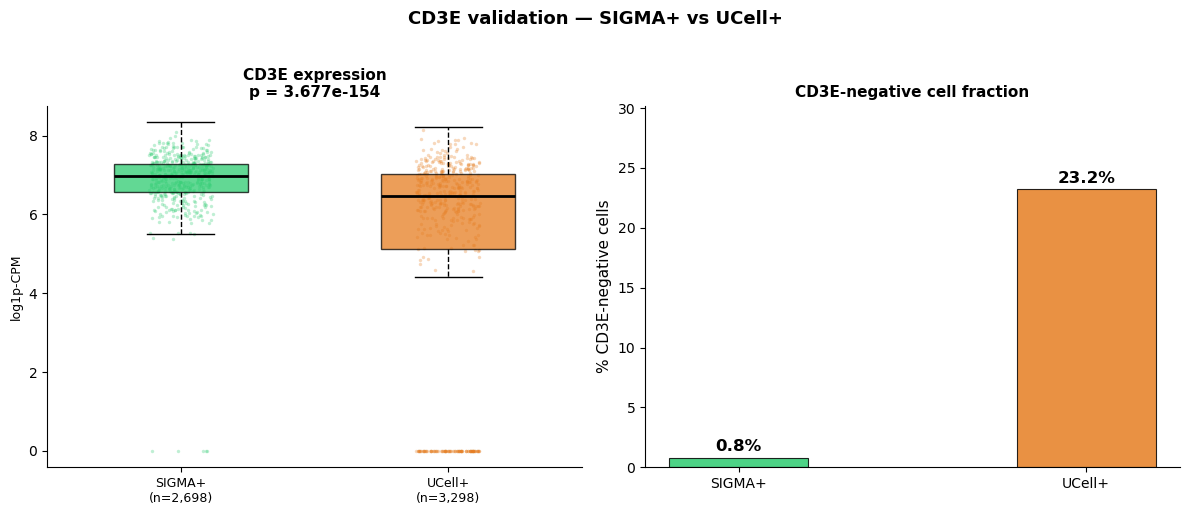

CD3E-negative : SIGMA+ = 0.8% | UCell+ = 23.2%


In [18]:
expr_cd3e_sigma = get_expression(adata_norm, mask_sigma.values, "CD3E")
expr_cd3e_ucell = get_expression(adata_norm, mask_ucell.values, "CD3E")

pct_neg_sigma = (expr_cd3e_sigma == 0).mean() * 100
pct_neg_ucell = (expr_cd3e_ucell == 0).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

boxplot_panel(axes[0], expr_cd3e_sigma, expr_cd3e_ucell,
              "CD3E expression", rng, n_sample=500)

ax = axes[1]
bars = ax.bar(["SIGMA+", "UCell+"],
              [pct_neg_sigma, pct_neg_ucell],
              color=[GREEN, ORANGE], alpha=0.85,
              width=0.4, edgecolor="black", linewidth=0.8)
for bar, pct in zip(bars, [pct_neg_sigma, pct_neg_ucell]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{pct:.1f}%", ha="center", va="bottom",
            fontsize=12, fontweight="bold")
ax.set_ylabel("% CD3E-negative cells", fontsize=11)
ax.set_title("CD3E-negative cell fraction", fontsize=11, fontweight="bold")
ax.set_ylim(0, max(pct_neg_sigma, pct_neg_ucell) * 1.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.suptitle("CD3E validation — SIGMA+ vs UCell+",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig("figures/sup_cd3e_validation.svg", bbox_inches="tight", dpi=500)
plt.show()

print(f"CD3E-negative : SIGMA+ = {pct_neg_sigma:.1f}% | "
      f"UCell+ = {pct_neg_ucell:.1f}%")

---
## 10. Figure 5 — Summary panel scores

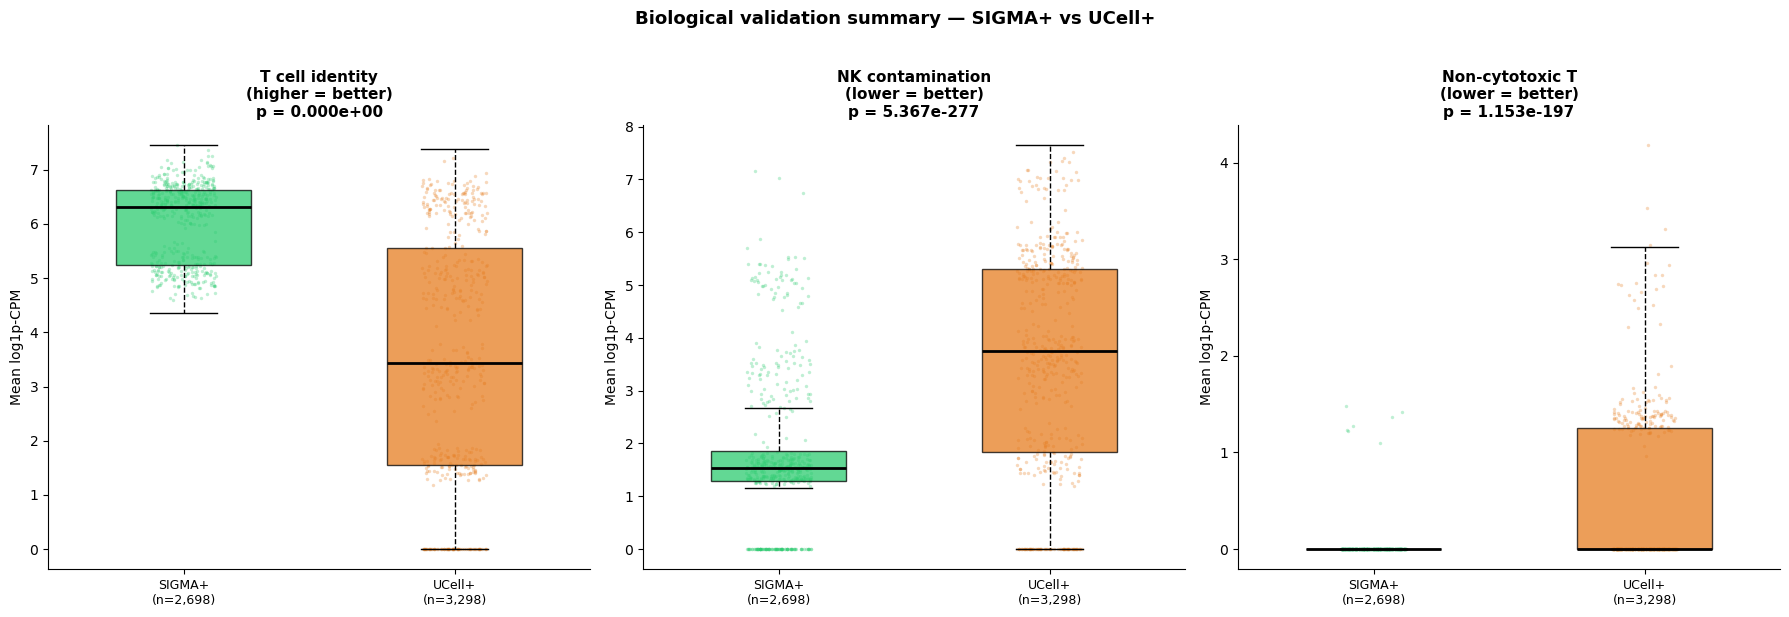

In [19]:
panels = [
    (T_CELL_MARKERS, "T cell identity\n(higher = better)"),
    (NK_MARKERS,     "NK contamination\n(lower = better)"),
    (NON_CYTOTOXIC,  "Non-cytotoxic T\n(lower = better)"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
rows = []

for ax, (genes, title) in zip(axes, panels):
    s = mean_panel(adata_norm, mask_sigma.values, genes)
    u = mean_panel(adata_norm, mask_ucell.values, genes)
    pval = boxplot_panel(ax, s, u, title, rng, n_sample=500)
    ax.set_ylabel("Mean log1p-CPM", fontsize=10)
    rows.append({"Panel": title.replace("\n", " "),
                 "SIGMA+ median": round(float(np.median(s)), 3),
                 "UCell+ median": round(float(np.median(u)), 3),
                 "p-value": format_pvalue(pval)})

fig.suptitle("Biological validation summary — SIGMA+ vs UCell+",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig("figures/sup_summary.svg", bbox_inches="tight", dpi=500)
plt.show()

---
## 11. Summary table

In [20]:
print("=== Selection overview ===")
print(f"SIGMA+  : {mask_sigma.sum():,}")
print(f"UCell+  : {mask_ucell.sum():,}  "
      f"(threshold = {ucell_threshold:.4f})")
print(f"Overlap : {(mask_sigma & mask_ucell).sum():,}")
print(f"\nCD3E-negative : SIGMA+ {pct_neg_sigma:.1f}% | "
      f"UCell+ {pct_neg_ucell:.1f}%")
print()
print(pd.DataFrame(rows).to_string(index=False))

=== Selection overview ===
SIGMA+  : 2,698
UCell+  : 3,298  (threshold = 0.5271)
Overlap : 261

CD3E-negative : SIGMA+ 0.8% | UCell+ 23.2%

                            Panel  SIGMA+ median  UCell+ median    p-value
T cell identity (higher = better)          6.312          3.427  0.000e+00
NK contamination (lower = better)          1.535          3.751 5.367e-277
 Non-cytotoxic T (lower = better)          0.000          0.000 1.153e-197
